In [6]:
# from phytclust import PhytClust
# from phytclust import plot_tree, plot_cluster
# from phytclust import pairwise_distances
# import phytclust.indices as pc
import io
import os
from Bio import Phylo
import sys
import numpy as np
import random
import matplotlib as mpl
import os
import datetime
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np

# universal_seed = 47  # Example seed
# random.seed(universal_seed)
# np.random.seed(universal_seed)
import csv
from sklearn.metrics.cluster import contingency_matrix
import glob
from sklearn.metrics import (
    adjusted_rand_score,
    v_measure_score,
    f1_score,
    accuracy_score,
    normalized_mutual_info_score,
)
import numpy as np
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder

In [184]:
name_folder = "N_100_K_20"
def extract_k_value(folder_name):
    parts = folder_name.split("_")
    print(parts)
    for i, part in enumerate(parts):
        if part == "K" and i + 1 < len(parts):
            return int(parts[i + 1])
    return None


k_value = extract_k_value(name_folder)
print(f"K = {k_value}")

['N', '100', 'K', '20']
K = 20


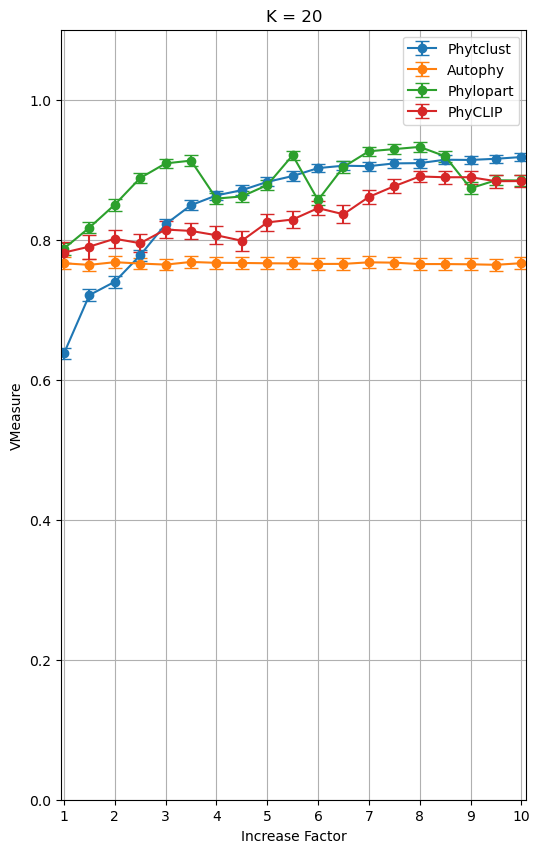

In [185]:
import os
import json
from statistics import mean
import os
import json
from statistics import mean
# name_folder = "N_100_K_5"
base_dir = f"/home/ganesank/project/phytclust/simulations_2/results/phytclust_results_all_k/{name_folder}"

wss_ari_dict = {}

# Iterate through each tree folder
for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "vmeasure_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    wss_value = float(entry["Tree"].split("_")[1])
                    ari_value = entry["VMeasure"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

phytclust_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}
# import os
# import json
# from statistics import mean

base_dir = f"/home/ganesank/project/phytclust/simulations_2/results/autophy_results/{name_folder}"

wss_ari_dict = {}

for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "validation_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    tree_name_parts = entry["Tree"].split("_")
                    wss_value = float(tree_name_parts[2])
                    ari_value = entry["VMeasure"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

autophy_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}
import os
import json
from statistics import mean

base_dir = f"/home/ganesank/project/phytclust/simulations_2/results/phylopart_results/{name_folder}"

wss_ari_dict = {}

for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "vmeasure_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    tree_name_parts = entry["Tree"].split("_")
                    wss_value = float(tree_name_parts[2])
                    ari_value = entry["VMeasure"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

phylopart_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}
import os
import json
from statistics import mean

base_dir = f"/home/ganesank/project/phytclust/simulations_2/results/phyclip_output/{name_folder}"
wss_ari_dict = {}
for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "vmeasure_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    tree_name_parts = entry["Subfolder"].split("_")
                    wss_value = float(tree_name_parts[2])
                    ari_value = entry["VMeasure"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

phyclip_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
    # phyclip_ari = {
    #     wss: (np.mean(ari_list), np.std(ari_list))
    #     for wss, ari_list in wss_ari_dict.items()
}
import matplotlib.pyplot as plt

# data_dicts = [random_ari, phytclust_ari, autophy_ari, treecluster_ari, phylopart_ari, phyclip_ari]
data_dicts = [
    phytclust_ari,
    autophy_ari,
    phylopart_ari,
    phyclip_ari,
]

labels = [
    "Phytclust",
    "Autophy",
    "Phylopart",
    "PhyCLIP",
]

plt.figure(figsize=(6, 10))

for data, label in zip(data_dicts, labels):
    # Filter out the thresholds outside the range 1.0 to 0.2
    filtered_data = {k: v for k, v in data.items()}
    sorted_items = sorted(filtered_data.items(), key=lambda x: x[0], reverse=True)
    x, y_sem = zip(*sorted_items)
    x = [val * 0.5 for val in x]
    y, sem = zip(*y_sem)
    plt.errorbar(x, y, yerr=sem, marker="o", label=label, capsize=5)

plt.xlabel("Increase Factor")
plt.ylabel("VMeasure")
plt.xticks(sorted(filtered_data.keys(), reverse=True))
plt.title(f"K = {k_value}")
plt.ylim(0, 1.1)
plt.xlim(0.95, 10.1)
plt.legend()
plt.grid(True)
plt.show()

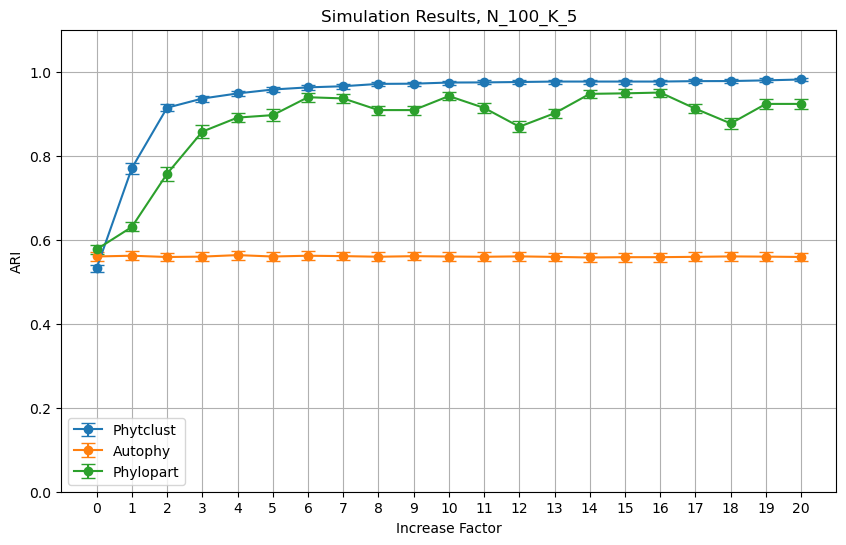

In [27]:
import os
import json
from statistics import mean
import os
import json
from statistics import mean

name_folder = "N_100_K_5"
base_dir = f"/home/ganesank/project/phytclust/simulations_2/results_fmi/phytclust_results_all_k/{name_folder}"

# Initialize a dictionary to store ARI values for each wss value
wss_ari_dict = {}

# Iterate through each tree folder
for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "comparison_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    wss_value = float(entry["Tree"].split("_")[1])
                    ari_value = entry["ARI"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

# Calculate the mean ARI for each wss value
phytclust_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}
import os
import json
from statistics import mean

# Define the path to the directory containing the tree folders
base_dir = f"/home/ganesank/project/phytclust/simulations_2/results_new/autophy_results/{name_folder}"

# Initialize a dictionary to store ARI values for each wss value
wss_ari_dict = {}

# Iterate through each tree folder
for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "ari_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    tree_name_parts = entry["Tree"].split("_")
                    wss_value = float(tree_name_parts[2])
                    ari_value = entry["ARI"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

# Calculate the mean ARI for each wss value
autophy_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}
import os
import json
from statistics import mean

# Define the path to the directory containing the tree folders
base_dir = f"/home/ganesank/project/phytclust/simulations_2/results_new/phylopart_results/{name_folder}"

# Initialize a dictionary to store ARI values for each wss value
wss_ari_dict = {}

# Iterate through each tree folder
for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "ari_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    tree_name_parts = entry["Tree"].split("_")
                    wss_value = float(tree_name_parts[2])
                    ari_value = entry["ARI"]
                    if wss_value not in wss_ari_dict:
                        wss_ari_dict[wss_value] = []
                    wss_ari_dict[wss_value].append(ari_value)

# Calculate the mean ARI for each wss value
phylopart_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}
import os
import json
from statistics import mean

# # Define the path to the directory containing the tree folders
# base_dir = f"/home/ganesank/project/phytclust/simulations_2/results_new/phyclip_output/{name_folder}"

# # Initialize a dictionary to store ARI values for each wss value
# wss_ari_dict = {}

# # Iterate through each tree folder
# for tree_folder in os.listdir(base_dir):
#     tree_path = os.path.join(base_dir, tree_folder)
#     if os.path.isdir(tree_path):
#         comparison_file = os.path.join(tree_path, "ari_results.json")
#         if os.path.isfile(comparison_file):
#             with open(comparison_file, "r") as file:
#                 data = json.load(file)
#                 for entry in data:
#                     tree_name_parts = entry["Subfolder"].split("_")
#                     wss_value = float(tree_name_parts[2])
#                     ari_value = entry["ARI"]
#                     if wss_value not in wss_ari_dict:
#                         wss_ari_dict[wss_value] = []
#                     wss_ari_dict[wss_value].append(ari_value)

# # Calculate the mean ARI for each wss value
# phyclip_ari = {
#     wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
#     for wss, ari_list in wss_ari_dict.items()
#     # phyclip_ari = {
#     #     wss: (np.mean(ari_list), np.std(ari_list))
#     #     for wss, ari_list in wss_ari_dict.items()
# }
import matplotlib.pyplot as plt

# Add more dictionaries as needed
# data_dicts = [random_ari, phytclust_ari, autophy_ari, treecluster_ari, phylopart_ari, phyclip_ari]
data_dicts = [
    phytclust_ari,
    autophy_ari,
    phylopart_ari,
    # phyclip_ari,
]

labels = [
    "Phytclust",
    "Autophy",
    "Phylopart",
    # "PhyCLIP",
]

# Prepare the plot
plt.figure(figsize=(10, 6))

# Plot each dictionary
for data, label in zip(data_dicts, labels):
    # Filter out the thresholds outside the range 1.0 to 0.2
    filtered_data = {k: v for k, v in data.items()}
    sorted_items = sorted(filtered_data.items(), key=lambda x: x[0], reverse=True)
    x, y_sem = zip(*sorted_items)
    y, sem = zip(*y_sem)
    plt.errorbar(x, y, yerr=sem, marker="o", label=label, capsize=5)

# Customize the plot
plt.xlabel("Increase Factor")
plt.ylabel("ARI")
plt.xticks(sorted(filtered_data.keys(), reverse=True))
plt.title(f"Simulation Results, {name_folder}")
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import os
import json
import numpy as np
from statistics import mean

# Define the path to the directory containing the tree folders
base_dir = "/home/ganesank/project/phytclust/simulations_2/unbalanced_trees_results/phytclust/N_20_K_4"

# Initialize a dictionary to store ARI values for each wss value
wss_ari_dict = {}

# Iterate through each tree folder
for tree_folder in os.listdir(base_dir):
    tree_path = os.path.join(base_dir, tree_folder)
    if os.path.isdir(tree_path):
        comparison_file = os.path.join(tree_path, "comparison_results.json")
        if os.path.isfile(comparison_file):
            with open(comparison_file, "r") as file:
                data = json.load(file)
                for entry in data:
                    if "ARI" in entry:  # Ensure ARI value is present
                        wss_value = float(entry["Tree"].split("_")[1])
                        ari_value = entry["ARI"]
                        if wss_value not in wss_ari_dict:
                            wss_ari_dict[wss_value] = []
                        wss_ari_dict[wss_value].append(ari_value)

# Calculate the mean ARI for each wss value
phytclust_ari = {
    wss: (np.mean(ari_list), np.std(ari_list) / np.sqrt(len(ari_list)))
    for wss, ari_list in wss_ari_dict.items()
}

# Add more dictionaries as needed
data_dicts = [phytclust_ari]
labels = [
    "Phytclust",
    # "Autophy",
    # "TreeCluster",
    # "Phylopart",
    # "PhyCLIP",
]  # Add more labels as needed

plt.figure(figsize=(10, 6))

# Plot each dictionary
for data, label in zip(data_dicts, labels):
    # Filter out the thresholds outside the range 1.0 to 0.2
    filtered_data = {k: v for k, v in data.items()}
    sorted_items = sorted(filtered_data.items(), key=lambda x: x[0])
    y_sem = [v for k, v in sorted_items]
    y, sem = zip(*y_sem)

    # Generate x-values starting from 1.0 and incrementing by 0.25
    x = np.arange(1.0, 1.0 + 0.25 * len(y), 0.25)

    plt.errorbar(x, y, yerr=sem, marker="o", label=label, capsize=5)

# Customize the plot
plt.xlabel("BSS/WSS Ratio")
plt.ylabel("ARI")
plt.title("Simulation Results, N=100, K=10")
plt.ylim(0, 1.2)

# Set x-axis ticks to start at 1.0 and increment by 0.25
x_ticks = np.arange(1.0, max(x) + 0.25, 0.25)
plt.xticks(x_ticks)

plt.legend()
plt.grid(True)

# Display the plot
plt.show()

# plotting random vs phytclust, given k

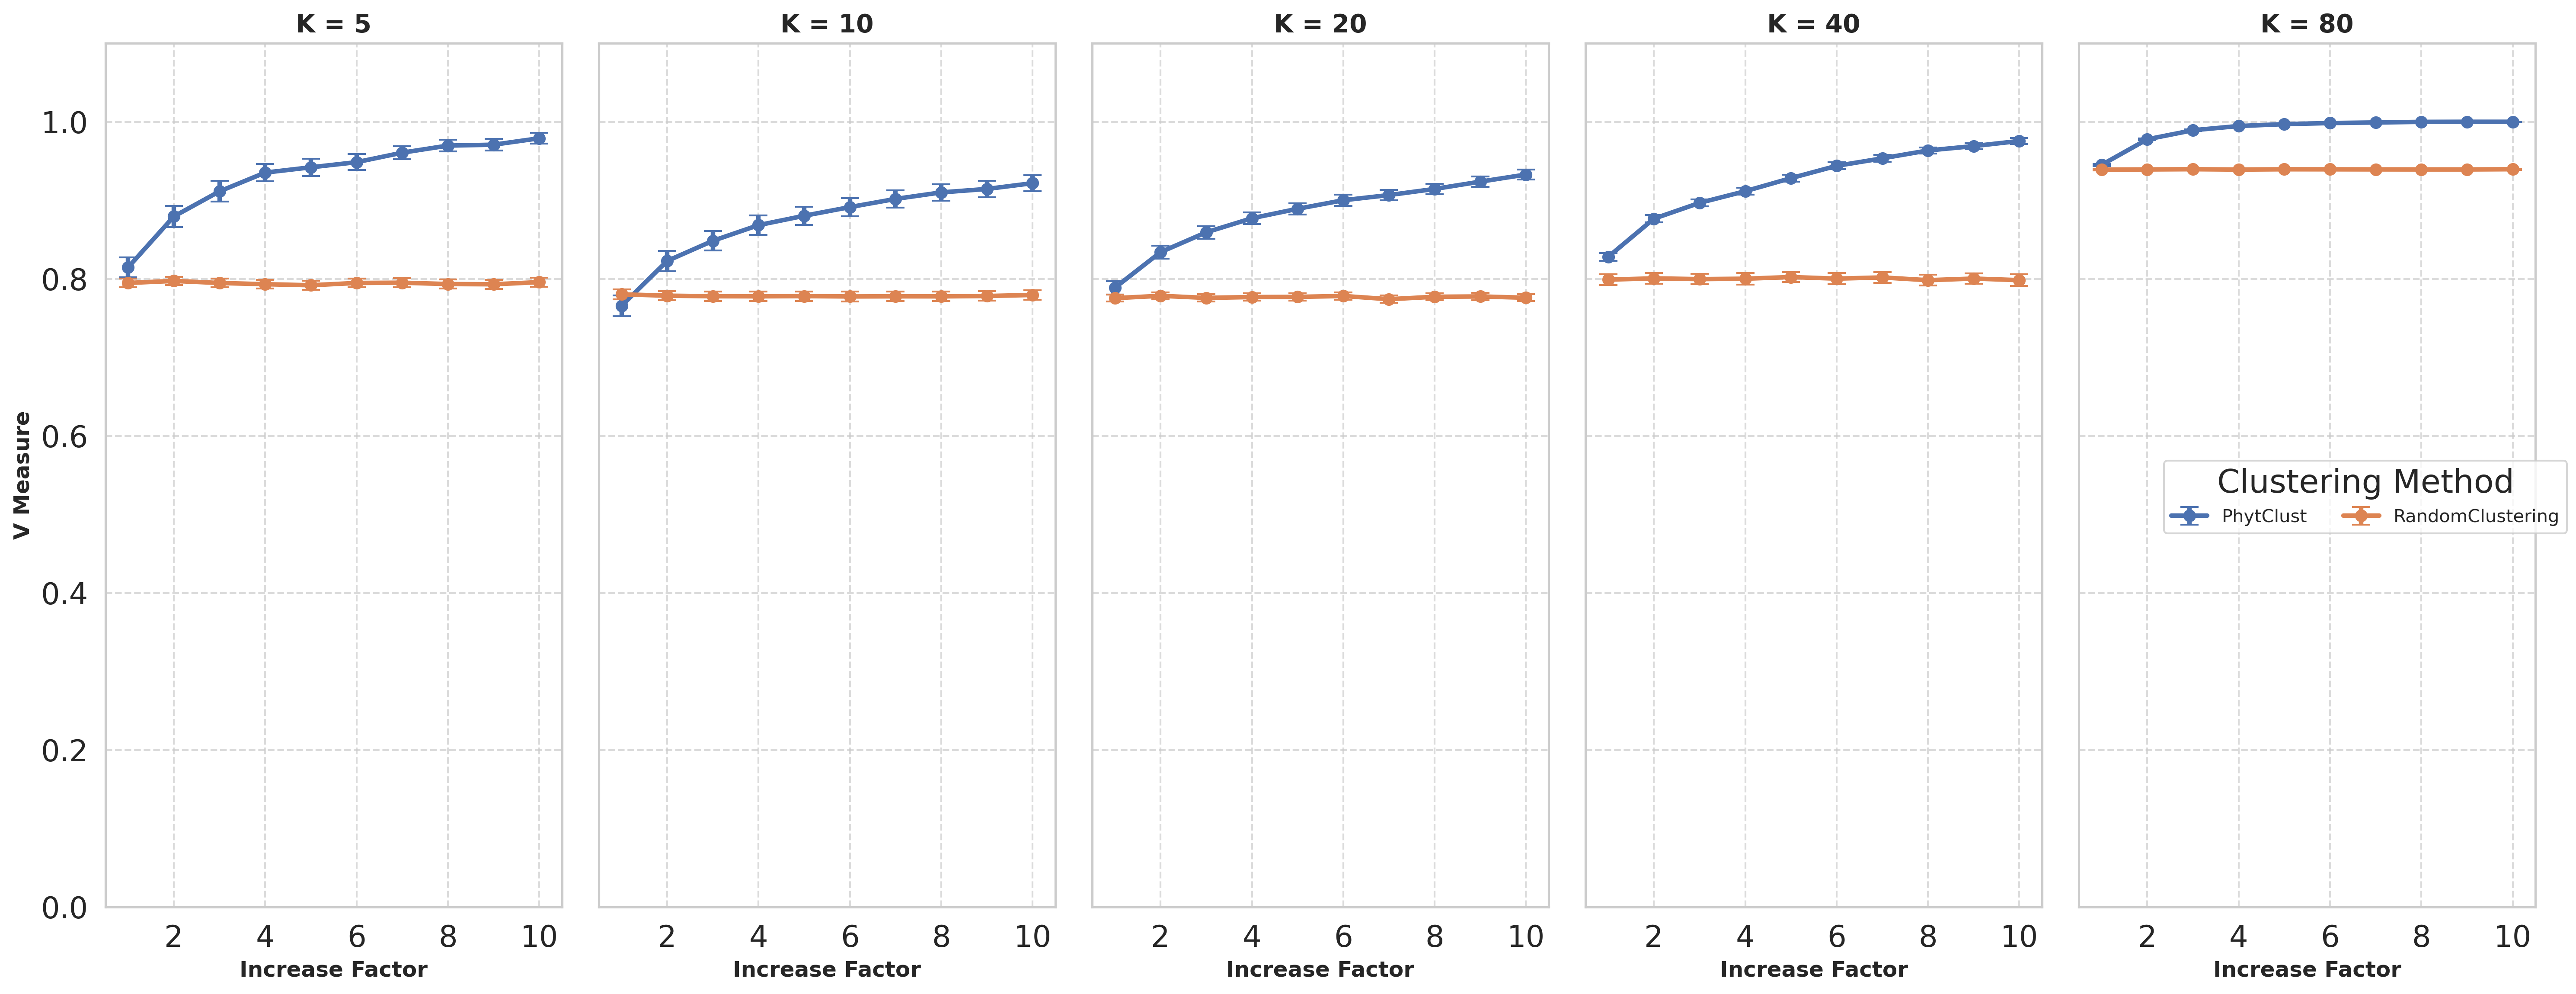

In [26]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style and context for publication-ready aesthetics
sns.set(style="whitegrid")
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})


def extract_v_measure_values(base_dir, is_random_k=False):
    wss_v_measure_dict = {}
    for tree_folder in os.listdir(base_dir):
        tree_path = os.path.join(base_dir, tree_folder)
        if os.path.isdir(tree_path):
            comparison_files = [
                os.path.join(tree_path, "comparison_results.json"),
                os.path.join(tree_path, "ari_results.json"),
            ]
            for comparison_file in comparison_files:
                if os.path.isfile(comparison_file):
                    with open(comparison_file, "r") as file:
                        data = json.load(file)
                        for entry in data:
                            if "Tree" in entry and "ARI" in entry:
                                tree_name_parts = entry["Tree"].split("_")
                                increase_value = int(tree_name_parts[1])
                                v_measure_value = entry["ARI"]
                                if increase_value not in wss_v_measure_dict:
                                    wss_v_measure_dict[increase_value] = []
                                wss_v_measure_dict[increase_value].append(
                                    (tree_folder, v_measure_value)
                                )
                    break
    return wss_v_measure_dict


def calculate_mean_sem(wss_v_measure_dict):
    return {
        wss: (
            np.mean([v_measure for _, v_measure in v_measure_list]),
            np.std([v_measure for _, v_measure in v_measure_list])
            / np.sqrt(len(v_measure_list)),
        )
        for wss, v_measure_list in wss_v_measure_dict.items()
    }


def plot_v_measure_panel(phytclust_v_measures, random_k_v_measures, titles, k_values):
    n_plots = len(phytclust_v_measures)
    fig, axes = plt.subplots(1, n_plots, figsize=(20, 8), dpi=300, sharey=True)

    for i, (phytclust_v_measure, random_k_v_measure, title, k_value) in enumerate(
        zip(phytclust_v_measures, random_k_v_measures, titles, k_values)
    ):
        ax = axes[i]

        for data, label in zip(
            [phytclust_v_measure, random_k_v_measure], ["PhytClust", "RandomClustering"]
        ):
            filtered_data = {k: v for k, v in data.items() if k != 0 and k <= 10}
            sorted_items = sorted(filtered_data.items())
            x, y_sem = zip(*sorted_items)
            y, sem = zip(*y_sem)
            ax.errorbar(x, y, yerr=sem, marker="o", label=label, capsize=5)

        # Set labels, title, and limits for each subplot
        ax.set_xlabel("Increase Factor", fontsize=12, weight="bold")
        ax.set_title(f"K = {k_value}", fontsize=14, weight="bold")
        ax.set_xlim(0.5, 10.5)
        ax.set_ylim(0, 1.1)
        ax.grid(True, linestyle="--", alpha=0.7)

    # Label y-axis only once for the shared axis
    axes[0].set_ylabel("V Measure", fontsize=12, weight="bold")

    # Add a single legend for the entire row at the top center
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="center right",
        title="Clustering Method",
        fontsize=10,
        ncol=2,
    )
    plt.tight_layout()
    plt.show()


base_dirs = [
    "/home/ganesank/project/phytclust/simulations_2/results_fmi/phytclust_single_k",
    "/home/ganesank/project/phytclust/simulations_2/results_fmi/random_single_k/",
]

# Lists to hold data for each plot
phytclust_v_measures = []
random_k_v_measures = []
titles = []
k_values = [5, 10, 20, 40, 80]  # Specified K values

# Only include directories that contain 'N_100' and match the specified K values
for k_value in k_values:
    nk_folder_name = f"N_100_K_{k_value}"
    phytclust_dir = os.path.join(base_dirs[0], nk_folder_name)
    random_k_dir = os.path.join(base_dirs[1], nk_folder_name)

    if os.path.isdir(phytclust_dir) and os.path.isdir(random_k_dir):
        phytclust_v_measure_dict = extract_v_measure_values(phytclust_dir)
        random_k_v_measure_dict = extract_v_measure_values(
            random_k_dir, is_random_k=True
        )

        phytclust_v_measure = calculate_mean_sem(phytclust_v_measure_dict)
        random_k_v_measure = calculate_mean_sem(random_k_v_measure_dict)

        phytclust_v_measures.append(phytclust_v_measure)
        random_k_v_measures.append(random_k_v_measure)
        titles.append(f"Simulation Results for {nk_folder_name}")

# Plot all results in a single row with specified K values
plot_v_measure_panel(phytclust_v_measures, random_k_v_measures, titles, k_values)